# PA5 — Step Counting with Embedded Sensing (Otter Edition)

**Course:** Embedded AI  
**Format:** Hybrid (concepts + coding)  
**Learning goals:**  
- Practice data ingestion and basic sensor preprocessing (vector magnitude, detrending).  
- Use a simple peak-detection algorithm to infer steps from accelerometer data.  
- (Mini AI) Engineer features and train a tiny classifier to distinguish *walking* vs *not walking*.  
- Explain design choices and limitations (concept questions).


> a phone/wearable uses a light-weight algorithm to estimate steps locally. We’ll also add a tiny model to classify simple activities to connect it back to AI/modeling.


## Setup

You can run this on your laptop or a hosted notebook. You'll need:
- `numpy`, `pandas`, `matplotlib`
- `scipy` (for detrending) – optional, we also show a mean-removal alternative
- `scikit-learn` (for the tiny classifier)
- `otter-grader` (only if you want to run local checks)

**Data:** Replace `PATH_TO/pace0.txt` with your file path. The expected columns are:  
`Time, AccelX, AccelY, AccelZ, (optional Gyro columns)`

If your file has headers or empty lines, use `pandas.read_csv(..., comment='#', skip_blank_lines=True)`.


## Sample Data:
path0.txt:

https://drive.google.com/file/d/1akQoy7i5Pz86exanaQ3K1zmOEQqx4v7z/view?usp=sharing


Read the given text file into a frame.

Your column headers are included in the file as: <br>
'Time (s)	X (m/s2)	Y (m/s2)	Z (m/s2)	R (m/s2)	Theta (deg)	Phi (deg)'

where

Time is sampling time in seconds

X, Y and Z are the acceleration in corresponding dimensions.

R, Theta and Phi is the angular velocity provided by the gyroscope:
https://en.wikipedia.org/wiki/Vibrating_structure_gyroscope#MEMS_gyroscopes

Acceloremeters help us estimate speed and the gyro aids in estimating orientation.

Both of these sensors are now common in most devices, including phones, laptops and robots.


Using `pandas` to read the csv file <br>
`pace0.txt`

The frame shape should be <br>
'(9228, 7)'

Here are the first lines:

```
!head pace0.txt

Keuwl Accelerometer Data File
2016-06-30 22-22-06

Time (s), X (m/s2), Y (m/s2), Z (m/s2), R (m/s2), Theta (deg), Phi (deg)
0.0000000,-0.366438,5.455855,7.333550,9.147764,36.709480,93.842453
0.0025065,-0.232317,5.530100,7.611372,9.411109,36.024586,92.405556
0.0050126,-0.201182,5.549261,7.855664,9.620095,35.255211,92.076279
0.0075456,-0.098196,5.501360,8.030500,9.734656,34.417660,91.022583
0.0100504,0.000000,5.431904,8.212523,9.846375,33.481339,90.000000
0.0125244,0.076641,5.453460,8.298743,9.930520,33.313225,89.194839
```

## Otter init (optional locally)

If you're running locally and want to see checks, uncomment the following:


In [ ]:
# import otter
# grader = otter.Notebook()  # optional local checks


## Part A — Concept Questions

Answer in the provided variables. Keep your answers short.


**Q1.** (MCQ) The primary reason to subtract the mean (detrend) from the accelerometer magnitude before peak detection is to:
- (A) reduce sensor bias (e.g., gravity on Z) so peaks are more comparable
- (B) increase sampling frequency
- (C) remove all noise
- (D) change the units from m/s² to steps/s

**Your answer:** set `q1_answer = "A" | "B" | "C" | "D"`


In [62]:
# BEGIN QUESTION 1
# TODO: set to one of "A","B","C","D"
q1_answer = "A"
# END QUESTION 1


**Q2.** (True/False) A fixed global threshold for peak detection will perform equally well for very slow walks and fast runs.


In [63]:
# BEGIN QUESTION 2
# TODO: set to True or False
q2_answer = False  # <-- EDIT HERE
# END QUESTION 2


**Q3.** (Short) In one sentence, explain why vector magnitude `sqrt(x^2 + y^2 + z^2)` is useful for phone orientation changes.


In [64]:
# BEGIN QUESTION 3
# TODO: write a short explanation (one sentence)
q3_answer = "the vector magnitude is useful for phone orientation changes because it combines the three individual axes into a single, stable value representing the total acceleration (including gravity), which remains constant regardless of how the phone is tilted."  # <-- EDIT HERE
# END QUESTION 3


## Part B — Data Loading & Preprocessing

**Tasks:**
1. Load the CSV/TXT file with time `t` (seconds) and accelerations `x, y, z` (m/s²).  
2. Compute vector magnitude: `mag = sqrt(x^2 + y^2 + z^2)`.  
3. Remove bias via mean subtraction: `mag_dt = mag - mean(mag)`.

Fill in the functions below.


In [65]:
# BEGIN QUESTION 4
import numpy as np
import pandas as pd

def load_accel(path):
    """
    Load accelerometer file.
    Expected columns: Time, AccelX, AccelY, AccelZ (tab/comma separated).
    Returns: t (np.ndarray), x, y, z
    """
    data = pd.read_csv(path, skiprows=3)

    data.columns = [col.strip() for col in data.columns]
    
    t = data['Time (s)'].to_numpy()
    x = data['X (m/s2)'].to_numpy()
    y = data['Y (m/s2)'].to_numpy()
    z = data['Z (m/s2)'].to_numpy()
    
    return t, x, y, z

def compute_magnitude(x, y, z):
    """Return sqrt(x^2 + y^2 + z^2) as a numpy array."""
    return np.sqrt(x**2 + y**2 + z**2)

def detrend_mean(mag):
    """Return mag_dt: mag - mean(mag)."""
    return mag - np.mean(mag)

# Example usage (edit path and uncomment after implementing):
t, x, y, z = load_accel("pace0.txt")
mag = compute_magnitude(x, y, z)
mag_dt = detrend_mean(mag)
# END QUESTION 4


## Setting it up
Plot the data:
- t vs x;
- t vs y and
- t vs z
in one figure

Example plot given below.

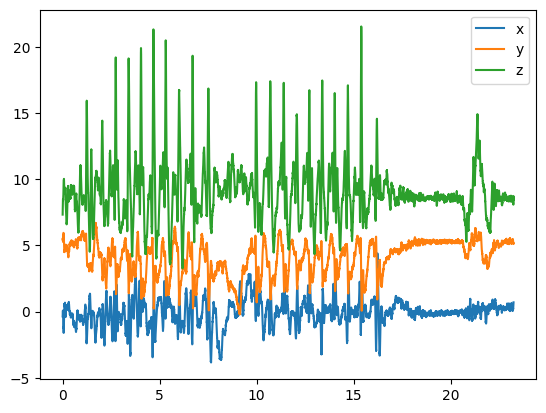

In [66]:
#plot the data:
# plot t vs x and t vs y and t vs z
#Example plot given below.  

#ENTER CODE HERE
import matplotlib.pyplot as plt
plt.plot(t,x, label="x")
plt.plot(t,y, label="y")
plt.plot(t,z, label="z")
plt.legend()
plt.show()


The figure should look like:
[accel](https://drive.google.com/file/d/1ag5mfadZP9S-ee5bO5UeyxHUpFei1xnC/view?usp=sharing)

You are seeing the accel data in 3 directions.

In this case, I am pacing my apartment and take: <br>
> 10 steps, pause, 10 more steps, pause, squat

Our goal is to estimate the number of steps I have taken during this data colleciton.

The answer sould be `21`

For now, let's get some info about the data:

What is our sampling time?


In [67]:
#Calculate the sensor's sampling time by looking that the difference between time steps
dt=np.diff(t)
fs = 1/np.mean(dt)
print("Average smapling time is %.2f Hz" % fs)
print("This means that data from sensors is arriving at every %.4f sec" % (1/fs))

# Average smapling time is 396.87 Hz
# This means that data from sensors is arriving at every 0.0025 sec

Average smapling time is 396.87 Hz
This means that data from sensors is arriving at every 0.0025 sec


### mag
We need to calculate the max change in accel to estimate the number of steps.

I was holding the phone upside up, so the 'z' direction carries most of the information in this case.

However, we need the algo to be direction agnostic.

Half the population may not have back pockets to store their phones in this orientation.

##### mag Problem
Find the max change in the acceleration, regardless of the phone orientation

Write vectorized code to calculate:
$$ \text{mag} = \sqrt{ x^2 + y^2 + z^2} $$

### detrending
Notice from the plot above that `z` direction has a bias. It hovers around ~$10 m/s^2$.

That is because of gravity acting upon the phone ($9.81 m/s^2$).

We need to eliminate this by `detrending` our data.

This is a common operation when deleaing with time series datasets that are `non-stationary`.

There are different ways of achieving this that includes differentiating the data and using linear regression.

#### detrending Problem

For our case, removing the mean will fix our issue.

Calculate a version of `mag` without a bias:
$$ mag\_dt = mag - mean(mag) $$

This is called `preprocessing` and it will minimize the effects of gravity on z direction and will avoid biasing our results.

#### Viz Problem
Plot the data the detrended mag vs original mag.

Sample plot is [here](https://drive.google.com/file/d/1aepaJT1W89eOatuTvR_8ZXIDdb2xyuww/view?usp=drive_link).


We are now ready to do our algo!

## Problem
Our goal is to estimate the number of steps.

Notice from the figure above that each peak in `mag` corresponds to a step.

So, count the number of peaks!

See the docstring for `detect_peaks` [here](https://github.com/demotu/detecta/blob/master/detecta/detect_peaks.py) or [there](https://github.com/demotu/BMC/blob/master/functions/detect_peaks.py)

We will tune `detect_peaks` to get our bitfit working.

We need the `mph`, `mpd` and `edge` options set correctly to have a robust solution.

Sample output plot is [here](https://drive.google.com/file/d/1afkspObbHSELgGLwUFCSMQB-EMZio69_/view?usp=sharing)

## Part C — Peak Detection (Step Counting)

Implement a simple peak detector with:
- minimum peak distance (in samples)
- optional minimum height

Return both the peak indices and the detrended magnitude for plotting.


In [68]:
# BEGIN QUESTION 5
def simple_peak_detect(signal, min_distance=20, height=None):
    """
    Lightweight peak detection without scipy.
    min_distance: minimum samples between peaks
    height: optional minimum height
    Returns: indices (np.ndarray)
    """
    
    # set a default height if None
    if height is None:
        height = np.min(signal) - 1.0

    N = len(signal)
    
    # 1. find all potential peaks (local maxima > height)
    potential_indices = []
    for i in range(1, N - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1] and signal[i] >= height:
            potential_indices.append(i)

    if not potential_indices:
        return np.array([], dtype=int)

    # 2. sort these peaks by their value (highest first)
    peak_values = signal[potential_indices]
    sorted_order = np.argsort(peak_values)[::-1] # indices for sorting

    # 3. enforce min_distance
    # we will use a boolean mask to track which peaks to keep
    keep_peak = np.ones(len(potential_indices), dtype=bool)
    final_peak_indices = []

    for i in sorted_order:
        if keep_peak[i]:
            # this is a valid peak. Keep it.
            current_peak_index = potential_indices[i]
            final_peak_indices.append(current_peak_index)
            
            # now, mask out all other *potential* peaks within min_distance
            for j in range(len(potential_indices)):
                if keep_peak[j] and i != j:
                    other_peak_index = potential_indices[j]
                    if np.abs(current_peak_index - other_peak_index) < min_distance:
                        keep_peak[j] = False # mask this peak

    # 4. return peaks sorted by their index in the signal
    return np.array(sorted(final_peak_indices))


def step_master(t, x, y, z, min_distance=20, height=None):
    """Compute mag -> detrend -> detect peaks. Return (peak_idx, mag_dt)."""
    # this function works exactly the same
    mag = compute_magnitude(x, y, z)
    mag_dt = detrend_mean(mag)
    peak_idx = simple_peak_detect(mag_dt, min_distance=min_distance, height=height)
    return peak_idx, mag_dt
# END QUESTION 5


In [69]:
# from detect_peaks import detect_peaks

#Sample logic for tuning detect_peaks parameters:

# Hints:
#1) Estimate max peak width / seperation:
# how many steps per sec can I take while walking?
# seperate peaks by x samples to avoid multiple detections per step
# make this dependent on fs.
# mpd = ?

#2) Estimate the min peak height:
# This will allow us to eliminate false positives that have shorter peaks.
# You can make this a parameter of a data stat, or test to find a good value
# mph =?

# 3) Edge detection:
#For a step: are we interested in a rising edge, falling edge or both?
#Set this value accordingly.
#edge = ?

#Sample plot is shown below.
#Notice that each step is marked and
# total number of steps is included in the title.


### Quick Plot (optional)

Uncomment and set your path to see the result.


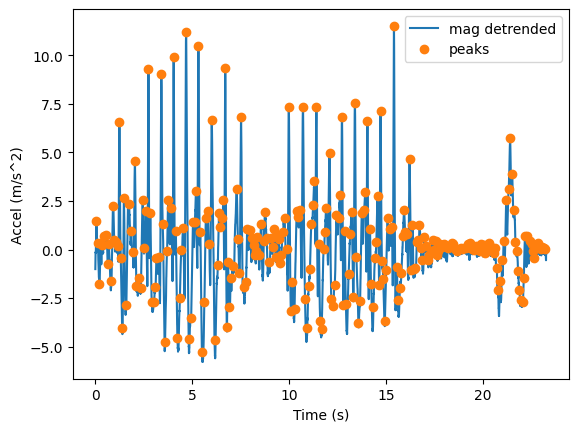

In [70]:
import matplotlib.pyplot as plt
t, x, y, z = load_accel("pace0.txt")
peaks, mag_dt = step_master(t, x, y, z, min_distance=25, height=None)
plt.figure()
plt.plot(t, mag_dt, label="mag detrended")
plt.plot(t[peaks], mag_dt[peaks], "o", label="peaks")
plt.xlabel("Time (s)"); plt.ylabel("Accel (m/s^2)"); plt.legend(); plt.show()


## Part D — Mini AI: Tiny Classifier (+ Confidence)

Create simple windowed features from `mag_dt` (e.g., mean, std, max, zero-crossings) and train a tiny classifier to label windows as *walking* vs *not walking*. If you only have walking data, fabricate a small *not walking* segment by selecting pauses/idle periods.

**Steps:**
1. Slice `mag_dt` into fixed windows (e.g., 2 seconds).  
2. Compute a small feature vector per window.  
3. Label windows.  
4. Train a `LogisticRegression` (or `KNeighborsClassifier`).  
5. Report accuracy with a held-out split.  
6. **Add a confidence readout:** for logistic regression, use `predict_proba` and report the probability of the predicted class for each window.


In [71]:
# BEGIN QUESTION 6
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

def window_features(mag_dt, fs, win_sec=2.0):
    """Return an array of windowed features for mag_dt (one row per window)."""
    
    win_samples = int(win_sec * fs)
    
    # calculate number of full windows
    n_windows = len(mag_dt) // win_samples
    
    features = []
    for i in range(n_windows):
        start = i * win_samples
        end = start + win_samples
        
        window = mag_dt[start:end]
        
        # extract features for this window
        feat_mean = np.mean(window)
        feat_std = np.std(window)
        feat_max = np.max(window)
        # you could add more, like zero-crossings, but these are a good start
        
        features.append([feat_mean, feat_std, feat_max])
    
    return np.array(features)

# example scaffold (complete after implementing the above):

# 1. load data and get mag_dt (should be run from Part B/C)
# ensure t, x, y, z are loaded, and fs is calculated
if 'fs' not in locals():
    t, x, y, z = load_accel(PATH_TO_FILE)
    dt = np.diff(t)
    fs = 1/np.mean(dt)
    _, mag_dt = step_master(t, x, y, z) # rerunning to get mag_dt

# 2. get features
X = window_features(mag_dt, fs, win_sec=2.0)

# 3. create labels (y)
# we have ~23.2 seconds of data, so 11 windows of 2s each.
# from the plot and description ("10 steps, pause, 10 more, pause, squat"):
# window 0 (0-2s): pause (0)
# window 1 (2-4s): walk (1)
# window 2 (4-6s): walk (1)
# window 3 (6-8s): pause (0)
# window 4 (8-10s): pause (0)
# window 5 (10-12s): walk (1)
# window 6 (12-14s): walk (1)
# window 7 (14-16s): pause (0)
# window 8 (16-18s): pause (0)
# window 9 (18-20s): squat (treat as activity '1')
# window 10 (20-22s): pause (0)
y = np.array([0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0])

# ensure X and y match in length
X = X[:len(y)]

# 4. split and train
# test_size=0.3 on 11 samples -> 3 test samples. stratify=y is crucial.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

clf = LogisticRegression(max_iter=200).fit(X_tr, y_tr)

# 5. report accuracy
acc = clf.score(X_te, y_te)
print(f"Accuracy: {acc:.4f}")

# 6. confidence readout per test window:
proba = clf.predict_proba(X_te)  # shape: [n_windows, n_classes]
y_hat = clf.predict(X_te)

# for each window, confidence of predicted class:
# we find the probability of the class that was *actually* predicted
conf = proba[np.arange(len(y_hat)), y_hat]

print(f"\nTest Predictions: {y_hat}")
print(f"True Labels:      {y_te}")
print(f"Confidence of Predictions: {np.round(conf, 3)}")
print(f"Mean predicted confidence: {float(np.mean(conf)):.4f}")
# END QUESTION 6

Accuracy: 0.7500

Test Predictions: [0 0 0 1]
True Labels:      [0 0 1 1]
Confidence of Predictions: [0.523 0.569 0.626 0.544]
Mean predicted confidence: 0.5658


## Public sanity checks (optional)

These are minimal, student-visible checks. They won't reveal solutions but can catch shape/type issues.
Uncomment after you implement the functions.


In [72]:
# import numpy as np
# # Q1-Q3 checks
# assert q1_answer in ["A","B","C","D"], "Q1 should be A/B/C/D"
# assert isinstance(q2_answer, (bool, np.bool_)), "Q2 must be True/False"
# assert isinstance(q3_answer, str) and len(q3_answer) >= 5, "Q3 needs a short sentence"
# # Q4-Q5-Q6 minimal shape checks will be exercised by Otter tests.


## Rubric (100 pts total)

| Part | Item | Points |
|---|---|---:|
| A | Q1 MCQ | 4 |
| A | Q2 True/False | 4 |
| A | Q3 Short explanation | 8 |
| B | Data loading & magnitude & detrend (`load_accel`, `compute_magnitude`, `detrend_mean`) | 18 |
| C | Peak detection (`simple_peak_detect`) + pipeline (`step_master`) | 26 |
| D | Feature engineering + split + training | 20 |
| D | **Confidence readout** (`predict_proba` & summary) | 10 |
| — | Code quality & clarity (docstrings, comments) | 10 |

**Notes:**  
- Reasonable variations in implementations are accepted if behavior matches.  
- Confidence can be mean predicted probability, or a short discussion justifying the metric.


## Submission

- Run all cells end-to-end, ensure no errors.
- If using Otter locally, you can export:
```python
# grader.export()  # creates a zip to upload to Gradescope
```
- Otherwise, just submit the notebook and any required data per your LMS instructions.
